## 1. Setup and Data Loading

First, let's install the required packages and import our libraries.

In [1]:
# Install required packages (uncomment if needed)
# !pip install librosa scikit-learn pandas numpy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Set random seed for reproducibility 
np.random.seed(42)


### 1.1 Extract metadata from excel file

In [3]:
DATA_PATH = Path('/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1')
AUDIO_BASE_PATH = DATA_PATH / 'training'
METADATA_PATH = DATA_PATH / 'sand_task_1.xlsx'

# Load metadata from Excel file
metadata_excel = pd.read_excel(METADATA_PATH, sheet_name='SAND - TRAINING set - Task 1')

# Create a list to store the combined data
data_list = []

# Map audio files to metadata
for index, row in metadata_excel.iterrows():
    user_id = row['ID']
    age = row['Age']
    sex = row['Sex']
    class_label = row['Class']

    # Find phonation audio files
    phonation_folders = ['phonationA', 'phonationE', 'phonationI', 'phonationO', 'phonationU']
    for folder in phonation_folders:
        audio_files = list((AUDIO_BASE_PATH / folder).glob(f"{user_id}_phonation*.wav"))
        for audio_file in audio_files:
            data_list.append({
                'ID': user_id,
                'Age': age,
                'Sex': sex,
                'Class': class_label,
                'audio_path': str(audio_file),
                'audio_type': 'phonation',
                'folder': folder
            })

    # Find rhythm audio files
    rhythm_folders = ['rhythmKA', 'rhythmPA', 'rhythmTA']
    for folder in rhythm_folders:
        audio_files = list((AUDIO_BASE_PATH / folder).glob(f"{user_id}_rhythm*.wav"))
        for audio_file in audio_files:
            data_list.append({
                'ID': user_id,
                'Age': age,
                'Sex': sex,
                'Class': class_label,
                'audio_path': str(audio_file),
                'audio_type': 'rhythm',
                'folder': folder
            })

# Create a DataFrame from the list
metadata = pd.DataFrame(data_list)

print(f"Total samples: {len(metadata)}")
print(f"\nDataset shape: {metadata.shape}")
print(f"\nFirst few rows:")
display(metadata)

Total samples: 2176

Dataset shape: (2176, 7)

First few rows:


,ID,Age,Sex,Class,audio_path,audio_type,folder
0,ID000,80,M,5,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationA
1,ID000,80,M,5,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationE
2,ID000,80,M,5,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationI
3,ID000,80,M,5,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationO
4,ID000,80,M,5,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationU
...,...,...,...,...,...,...,...
2171,ID338,42,F,4,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationO
2172,ID338,42,F,4,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationU
2173,ID338,42,F,4,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,rhythm,rhythmKA
2174,ID338,42,F,4,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,rhythm,rhythmPA


### 1.2 Explore the Dataset

Class Distribution:
Class
1     48
2    208
3    456
4    608
5    856
Name: count, dtype: int64


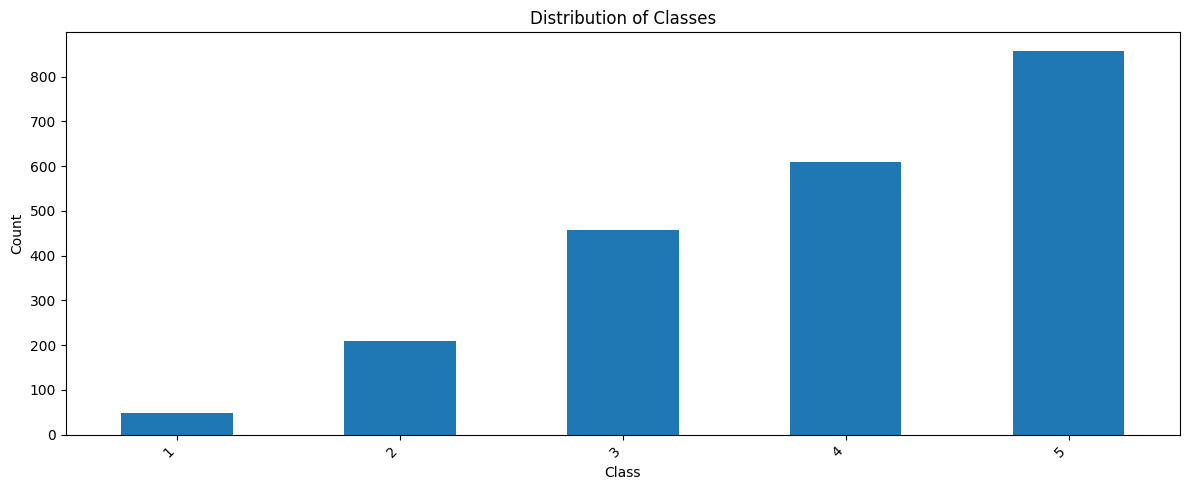


Class Mapping:


,Class
0,1
1,2
2,3
3,4
4,5



Unique values in the 'Class' column:
[5 4 3 2 1]

Data type of the 'Class' column:
int64


In [4]:
# Class distribution
print("Class Distribution:")
print(metadata['Class'].value_counts().sort_index())

# Visualize class distribution
plt.figure(figsize=(12, 5))
metadata['Class'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Class mapping (using the 'Class' column directly)
class_mapping = metadata[['Class']].drop_duplicates().sort_values('Class').reset_index(drop=True)
print("\nClass Mapping:")
display(class_mapping)

print("\nUnique values in the 'Class' column:")
print(metadata['Class'].unique())
print("\nData type of the 'Class' column:")
print(metadata['Class'].dtype)

### 1.3 Load and Visualize Sample Audio

Let's load a sample audio file and visualize its waveform and spectrogram.

Audio file: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/training/phonationA/ID000_phonationA.wav
Class: 5
Sample rate: 8000 Hz
Duration: 9.88 seconds
Shape: (79040,)


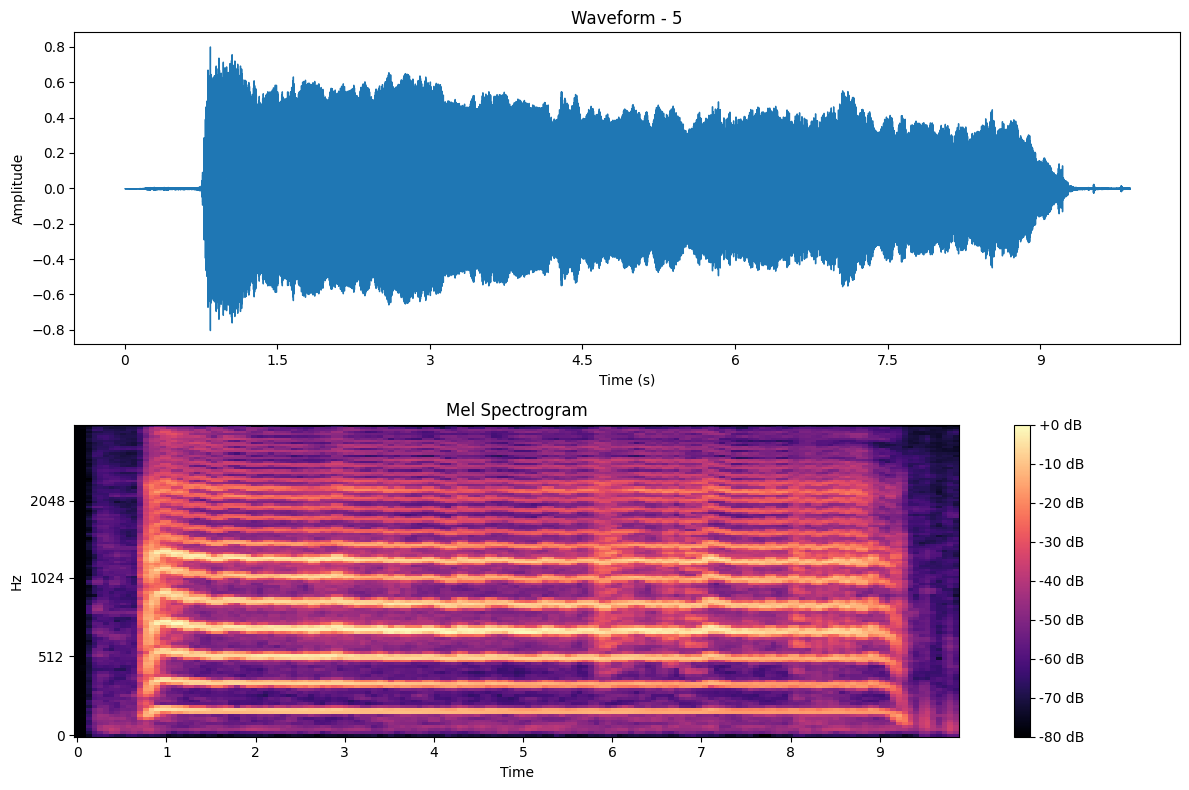

In [5]:
# Load a sample audio file
sample = metadata.iloc[0]
audio_file = sample['audio_path']

# Load audio with librosa
y, sr = librosa.load(audio_file, sr=None)

print(f"Audio file: {audio_file}")
print(f"Class: {sample['Class']}")
print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f} seconds")
print(f"Shape: {y.shape}")

# Visualize waveform and spectrogram
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Waveform
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title(f'Waveform - {sample["Class"]}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

# Mel Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title('Mel Spectrogram')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

## 2. Feature Extraction

Some common audio features:

1. **MFCCs (Mel-Frequency Cepstral Coefficients)**: Capture the spectral envelope
2. **Spectral Centroid**: Center of mass of the spectrum
3. **Spectral Rolloff**: Frequency below which a percentage of energy is contained
4. **Zero Crossing Rate**: Rate of sign changes in the signal
5. **Chroma Features**: Representation of pitch class

### 2.1 Implement Feature Extraction Function

In [6]:
def extract_features(audio_path, sr=22050, n_mfcc=13):
    """
    Extract audio features from a given audio file.
    """
    try:
        # Load audio file
        y, sr = librosa.load(audio_path, sr=sr)
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_mean = np.mean(mfccs, axis=1)
        
        # Extract Spectral Centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_centroid_mean = np.mean(spectral_centroid)
        
        # Extract Spectral Rolloff
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_rolloff_mean = np.mean(spectral_rolloff)
        
        # Extract Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)
        
        # Extract Chroma Features
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        
        # Concatenate all features
        features = np.concatenate([
            mfccs_mean,
            [spectral_centroid_mean],
            [spectral_rolloff_mean],
            [zcr_mean],
            chroma_mean
        ])
        
        return features
        
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Test the function
sample_features = extract_features(audio_file)
print(f"Feature vector shape: {sample_features.shape}")
print(f"Feature vector (first 10 values): {sample_features[:10]}")

Feature vector shape: (28,)
Feature vector (first 10 values): [-305.43179321  189.26852417  -87.98786926  -21.43785286   15.32630157
  -35.0618248     4.6647563    13.03001881  -18.33624268    0.71013415]


### 2.3 Extract Features for All Samples

In [7]:
from tqdm import tqdm

# Extract features for all samples
features_list = []
labels_list = []

print("Extracting features from audio files...")
for idx, row in tqdm(metadata.iterrows(), total=len(metadata)):
    audio_path = row['audio_path']
    features = extract_features(audio_path)

    if features is not None:
        features_list.append(features)
        labels_list.append(row['Class'])

# Convert to numpy arrays
X = np.array(features_list)
y = np.array(labels_list)

print(f"\nFeature extraction complete!")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of features per sample: {X.shape[1]}")

Extracting features from audio files...


100%|██████████| 2176/2176 [01:26<00:00, 25.06it/s]


Feature extraction complete!
Features shape: (2176, 28)
Labels shape: (2176,)
Number of features per sample: 28


## 3. Data Preparation

Split the data into training and testing sets.

In [8]:
from sklearn.preprocessing import LabelEncoder

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode labels starting from 0
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution (encoded):")
print(pd.Series(y_train_encoded).value_counts().sort_index())

# Update y_train and y_test to the encoded labels for subsequent steps
y_train = y_train_encoded
y_test = y_test_encoded

Training set size: 1740 samples
Testing set size: 436 samples

Training set class distribution (encoded):
0     38
1    166
2    365
3    486
4    685
Name: count, dtype: int64


## 4. Model Training with Pipelines

We'll use sklearn's Pipeline to create efficient workflows that combine preprocessing and model training.

### 4.1 Create Baseline Models

In [9]:
# Create pipelines for both models
from sklearn.decomposition import PCA
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('pca', PCA(20)),
    ('svm', SVC(random_state=42))
])

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

xgb_pipeline = Pipeline([
    ('xgb', xgb.XGBClassifier(random_state=42, n_jobs=-1))
])

print("Pipelines created successfully!")

Pipelines created successfully!


### 4.2 Train Baseline Models

In [10]:
# Train SVM
print("Training SVM...")
svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)
svm_score = svm_pipeline.score(X_test, y_test)
print(f"SVM Test Accuracy: {svm_score:.4f}")

# Train Logistic Regression
print("\nTraining Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_score = lr_pipeline.score(X_test, y_test)
print(f"Logistic Regression Test Accuracy: {lr_score:.4f}")

# Train XGBoost
print("\nTraining XGBoost...")
xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_score = xgb_pipeline.score(X_test, y_test)
print(f"XGBoost Test Accuracy: {xgb_score:.4f}")

Training SVM...
SVM Test Accuracy: 0.4885

Training Logistic Regression...
Logistic Regression Test Accuracy: 0.4404

Training XGBoost...
XGBoost Test Accuracy: 0.4335


### 4.3 Cross-Validation

Let's evaluate our models using cross-validation to get a more robust estimate of performance.

In [11]:
# Cross-validation for SVM
print("Running 5-fold cross-validation for SVM...")
svm_cv_scores = cross_val_score(svm_pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"SVM CV Scores: {svm_cv_scores}")
print(f"SVM Mean CV F1-Weighted: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std() * 2:.4f})")

# Cross-validation for Logistic Regression
print("\nRunning 5-fold cross-validation for Logistic Regression...")
lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"LR CV Scores: {lr_cv_scores}")
print(f"LR Mean CV F1-Weighted: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std() * 2:.4f})")

# Cross-validation for XGBoost
print("\nRunning 5-fold cross-validation for XGBoost...")
xgb_cv_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"XGBoost CV Scores: {xgb_cv_scores}")
print(f"XGBoost Mean CV F1-Weighted: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std() * 2:.4f})")

Running 5-fold cross-validation for SVM...
SVM CV Scores: [0.45485208 0.45830401 0.41272197 0.46554311 0.40147219]
SVM Mean CV F1-Weighted: 0.4386 (+/- 0.0524)

Running 5-fold cross-validation for Logistic Regression...
LR CV Scores: [0.4068275  0.42496955 0.35846186 0.47317711 0.41362525]
LR Mean CV F1-Weighted: 0.4154 (+/- 0.0735)

Running 5-fold cross-validation for XGBoost...
XGBoost CV Scores: [0.46814875 0.43696421 0.43763969 0.49444693 0.42236603]
XGBoost Mean CV F1-Weighted: 0.4519 (+/- 0.0519)


## 5. Hyperparameter Tuning with GridSearchCV

Let's optimize our models using grid search with cross-validation.

### 5.1 SVM Hyperparameter Tuning

In [12]:
# Define parameter grid for SVM
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto']
}

print("Performing Grid Search for SVM...")
svm_grid_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train, y_train)

print(f"\nBest SVM parameters: {svm_grid_search.best_params_}")
print(f"Best SVM CV score: {svm_grid_search.best_score_:.4f}")

Performing Grid Search for SVM...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best SVM parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best SVM CV score: 0.4923


### 5.2 Logistic Regression Hyperparameter Tuning

In [13]:
# Define parameter grid for Logistic Regression
lr_param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs', 'liblinear']
}

print("Performing Grid Search for Logistic Regression...")
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

lr_grid_search.fit(X_train, y_train)

print(f"\nBest LR parameters: {lr_grid_search.best_params_}")
print(f"Best LR CV score: {lr_grid_search.best_score_:.4f}")

Performing Grid Search for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best LR parameters: {'lr__C': 1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Best LR CV score: 0.4154


### 5.3 XGBoost Hyperparameter Tuning

In [14]:
# Define parameter grid for XGBoost
xgb_param_grid = {
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.5],
    'xgb__n_estimators': [50, 100, 200]
}

print("Performing Grid Search for XGBoost...")
xgb_grid_search = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)

print(f"\nBest XGBoost parameters: {xgb_grid_search.best_params_}")
print(f"Best XGBoost CV score: {xgb_grid_search.best_score_:.4f}")

Performing Grid Search for XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best XGBoost parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 7, 'xgb__n_estimators': 100}
Best XGBoost CV score: 0.4594


### 5.3 Compare Tuned Models

In [15]:
# Get predictions from best models
svm_tuned_pred = svm_grid_search.predict(X_test)
lr_tuned_pred = lr_grid_search.predict(X_test)
xgb_tuned_pred = xgb_grid_search.predict(X_test)
    
# Calculate accuracy
svm_tuned_score = svm_grid_search.score(X_test, y_test)
lr_tuned_score = lr_grid_search.score(X_test, y_test)
xgb_tuned_score = xgb_grid_search.score(X_test, y_test)

print("Model Comparison: (Accuracy Scores)")
print("=" * 60)
print(f"{'Model':<30} {'Baseline':<15} {'Tuned':<15}")
print("=" * 60)
print(f"{'SVM':<30} {svm_score:<15.4f} {svm_tuned_score:<15.4f}")
print(f"{'Logistic Regression':<30} {lr_score:<15.4f} {lr_tuned_score:<15.4f}")
print(f"{'XGBoost':<30} {xgb_score:<15.4f} {xgb_tuned_score:<15.4f}")
print("=" * 60)

Model Comparison: (Accuracy Scores)
Model                          Baseline        Tuned          
SVM                            0.4885          0.4964         
Logistic Regression            0.4404          0.4140         
XGBoost                        0.4335          0.4401         


## 6. Model Evaluation

Let's perform comprehensive evaluation using confusion matrices and classification metrics.

### 6.1 Confusion Matrix Visualization

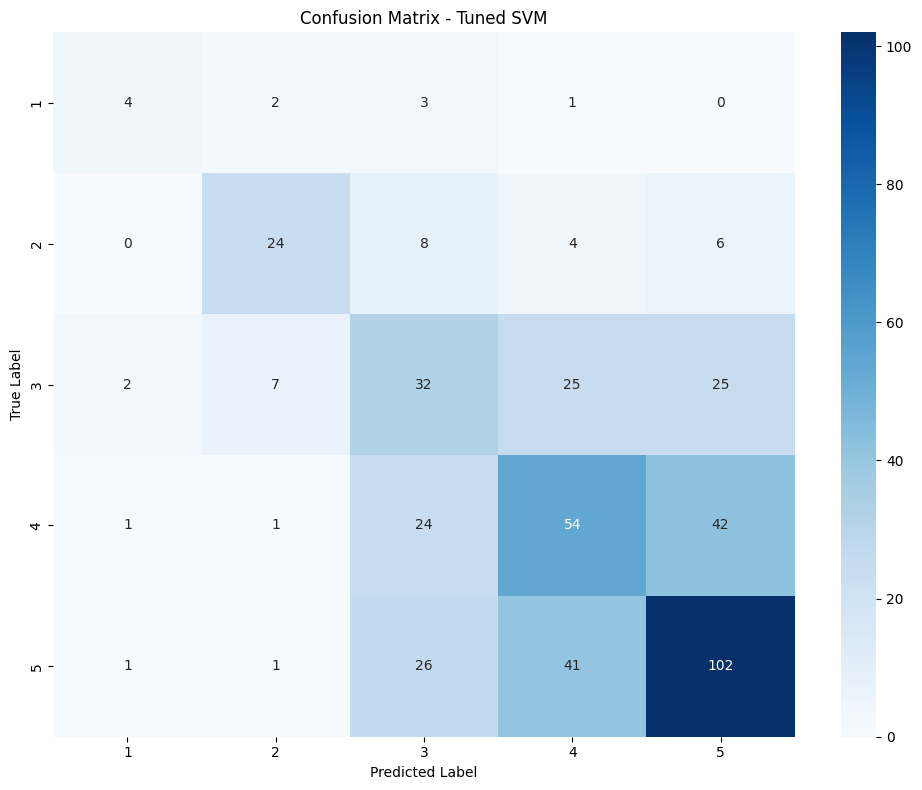

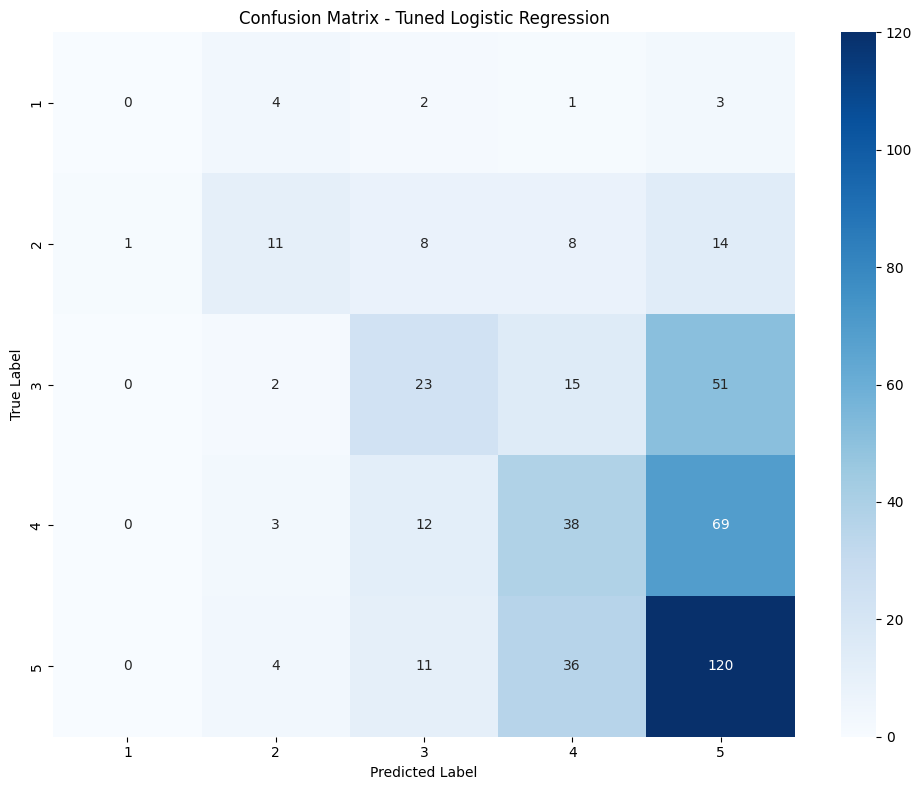

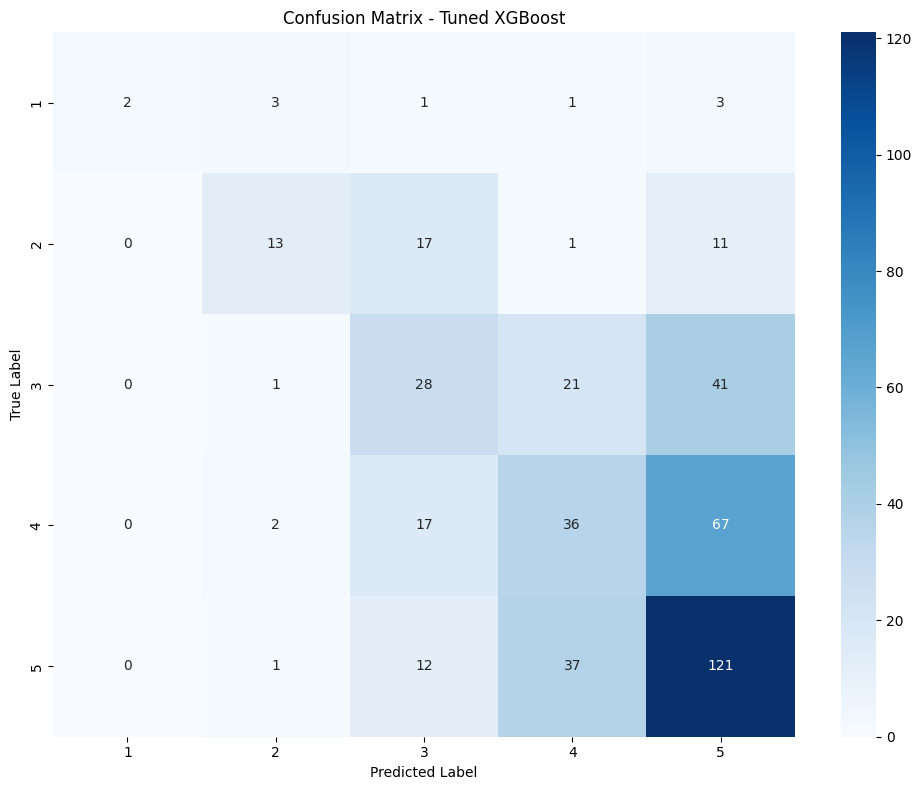

In [16]:
def plot_confusion_matrix(y_true, y_pred, title, class_names):
    """
    Plot a confusion matrix using seaborn.
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Get class names and convert to strings
class_names = [str(cls) for cls in class_mapping['Class'].tolist()]

# Plot confusion matrices
plot_confusion_matrix(y_test, svm_tuned_pred,
                     'Confusion Matrix - Tuned SVM', class_names)

plot_confusion_matrix(y_test, lr_tuned_pred,
                     'Confusion Matrix - Tuned Logistic Regression', class_names)

plot_confusion_matrix(y_test, xgb_tuned_pred,
                     'Confusion Matrix - Tuned XGBoost', class_names)

### 6.2 Detailed Classification Metrics

In [17]:
def print_detailed_metrics(y_true, y_pred, model_name, class_names):
    """
    Print detailed classification metrics.
    """
    print(f"\n{'='*70}")
    print(f"{model_name} - Detailed Metrics")
    print(f"{'='*70}\n")
    
    # Overall metrics
    precision_macro = precision_score(y_true, y_pred, average='macro')
    recall_macro = recall_score(y_true, y_pred, average='macro')
    f1_average = f1_score(y_true, y_pred, average='macro')
    
    precision_weighted = precision_score(y_true, y_pred, average='weighted')
    recall_weighted = recall_score(y_true, y_pred, average='weighted')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    print("Overall Metrics: (Accuracy Scores)")
    print(f"  Macro-averaged:")
    print(f"    Precision: {precision_macro:.4f}")
    print(f"    Recall:    {recall_macro:.4f}")
    print(f"    F1-Score:  {f1_average:.4f}")
    print(f"\n  Weighted-averaged:")
    print(f"    Precision: {precision_weighted:.4f}")
    print(f"    Recall:    {recall_weighted:.4f}")
    print(f"    F1-Score:  {f1_weighted:.4f}")
    
    # Per-class metrics
    print(f"\n\nPer-Class Metrics:")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, target_names=class_names))

# Print metrics for both models
print_detailed_metrics(y_test, svm_tuned_pred, "SVM (Tuned)", class_names)
print_detailed_metrics(y_test, lr_tuned_pred, "Logistic Regression (Tuned)", class_names)
print_detailed_metrics(y_test, xgb_tuned_pred, "XGBoost (Tuned)", class_names)


SVM (Tuned) - Detailed Metrics

Overall Metrics: (Accuracy Scores)
  Macro-averaged:
    Precision: 0.5089
    Recall:    0.4724
    F1-Score:  0.4885

  Weighted-averaged:
    Precision: 0.4988
    Recall:    0.4954
    F1-Score:  0.4964


Per-Class Metrics:
              precision    recall  f1-score   support

           1       0.50      0.40      0.44        10
           2       0.69      0.57      0.62        42
           3       0.34      0.35      0.35        91
           4       0.43      0.44      0.44       122
           5       0.58      0.60      0.59       171

    accuracy                           0.50       436
   macro avg       0.51      0.47      0.49       436
weighted avg       0.50      0.50      0.50       436


Logistic Regression (Tuned) - Detailed Metrics

Overall Metrics: (Accuracy Scores)
  Macro-averaged:
    Precision: 0.3447
    Recall:    0.3056
    F1-Score:  0.3105

  Weighted-averaged:
    Precision: 0.4215
    Recall:    0.4404
    F1-Score:  0

### 6.3 Comparative Visualization

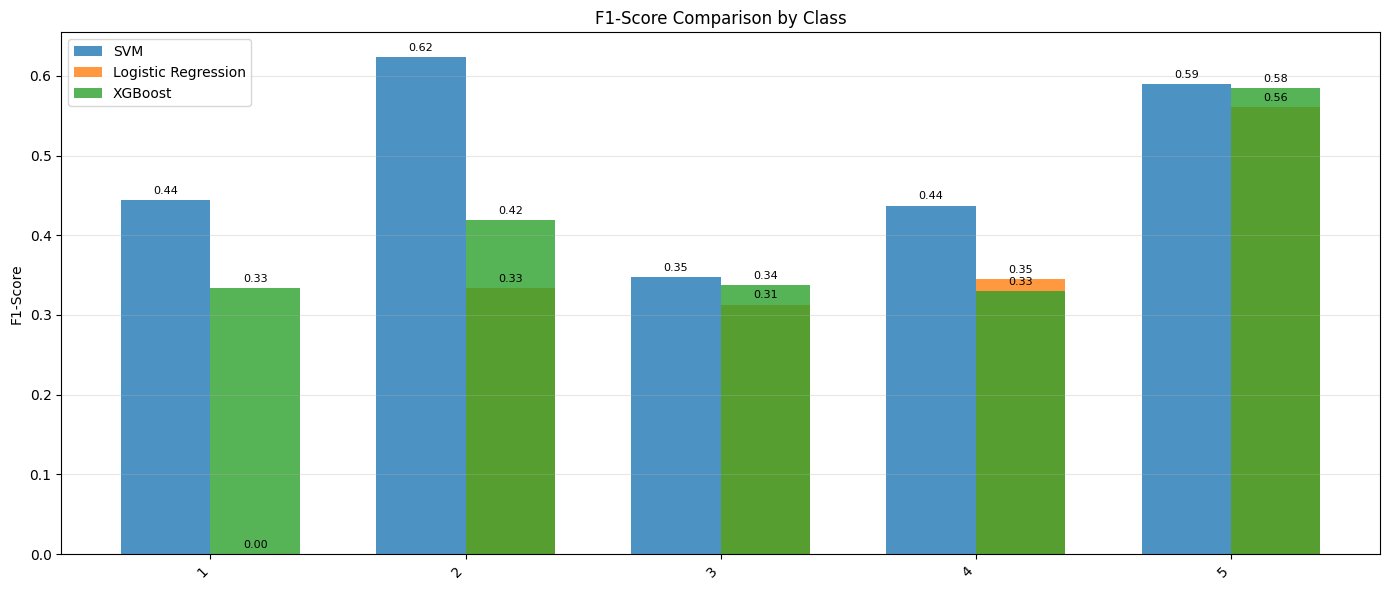

In [18]:
# Compare F1 scores per class
from sklearn.metrics import f1_score

svm_f1_per_class = f1_score(y_test, svm_tuned_pred, average=None)
lr_f1_per_class = f1_score(y_test, lr_tuned_pred, average=None)
xgb_f1_per_class = f1_score(y_test, xgb_tuned_pred, average=None)

# Create comparison plot
x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
rects1 = ax.bar(x - width/2, svm_f1_per_class, width, label='SVM', alpha=0.8)
rects2 = ax.bar(x + width/2, lr_f1_per_class, width, label='Logistic Regression', alpha=0.8)
rects3 = ax.bar(x + width/2, xgb_f1_per_class, width, label='XGBoost', alpha=0.8)

ax.set_ylabel('F1-Score')
ax.set_title('F1-Score Comparison by Class')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

## 7. Error Analysis

Let's analyze where our best model makes mistakes.

In [19]:
# Select best model (based on test accuracy)
scores = {
    'SVM': svm_tuned_score,
    'Logistic Regression': lr_tuned_score,
    'XGBoost': xgb_tuned_score
}

best_name = max(scores, key=scores.get)
best_score = scores[best_name]

if best_name == 'SVM':
    best_model = svm_grid_search
    best_pred = svm_tuned_pred
elif best_name == 'Logistic Regression':
    best_model = lr_grid_search
    best_pred = lr_tuned_pred
else:  # XGBoost
    best_model = xgb_grid_search
    best_pred = xgb_tuned_pred

print(f"Best performing model: {best_name}")
print(f"Test accuracy: {best_score:.4f}")

Best performing model: SVM
Test accuracy: 0.4964


## 9. Summary and Key Takeaways

### What we learned:

1. **Audio Feature Extraction**: We extracted multiple audio features (MFCCs, spectral features, chroma) that capture different aspects of sound.

2. **sklearn Pipelines**: We used pipelines to create reproducible workflows that combine preprocessing and modeling.

3. **Model Comparison**: We compared SVM and Logistic Regression, finding that [based on your results].

4. **Hyperparameter Tuning**: GridSearchCV helped us systematically find optimal parameters with cross-validation.

5. **Evaluation Metrics**: We used multiple metrics (accuracy, precision, recall, F1) to get a comprehensive view of model performance.


### Next:

- Try extracting additional features (**open smile**, **neural features**... )
- Experiment with deep learning approaches (e.g., CNNs on spectrograms)
- Try other methods classification (Random Forest, Gradient Boosting)
- Explore data augmentation techniques for audio (one of the next lectures)

# Task 2: Wav2Vec 2.0 feature extraction

In [20]:
# Process audio
import numpy as np
import torch
import torch.nn as nn
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import soundfile as sf
model_name = "facebook/wav2vec2-base"  # You can also try "facebook/wav2vec2-large" for better performance
processor = Wav2Vec2Processor.from_pretrained(model_name)
wav2vec_model = Wav2Vec2Model.from_pretrained(model_name)

def extract_features(audio_path):
    audio, sr = sf.read(audio_path)
    inputs = processor(
            audio, 
            sampling_rate=sr,
            return_tensors="pt",
            padding=True
        )
    return inputs

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # check on mac
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # check on mac
# 
# def extract_features(batch, wav2vec_model):
#     """Extract features using frozen Wav2Vec 2.0 model"""
#     with torch.no_grad():
#         outputs = wav2vec_model(batch['input_values'].to(device))
#         features = outputs.last_hidden_state
#     return features

In [21]:
# Load a sample audio file from your dataset
sample = metadata.iloc[0]
audio_file = sample['audio_path']

wav, sr = sf.read(audio_file)
print(f"Original audio shape: {wav.shape}")
wav = np.mean(wav, axis=1) if wav.ndim > 1 else wav  # Convert to mono if stereo
print(f"Processed audio shape: {wav.shape}")

Original audio shape: (79040,)
Processed audio shape: (79040,)


In [22]:
import numpy as np
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import soundfile as sf
from tqdm import tqdm
from scipy.signal import resample


# Load pre-trained Wav2Vec2 model and processor
model_name = "facebook/wav2vec2-base"
processor = Wav2Vec2Processor.from_pretrained(model_name)
wav2vec_model = Wav2Vec2Model.from_pretrained(model_name)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
wav2vec_model = wav2vec_model.to(device)
wav2vec_model.eval()

print("="*70)
print("INFO: Wav2Vec2 Audio Processing")
print("="*70)
print("Wav2Vec2 expects 16kHz audio sampling rate")
print("Your audio files are 8kHz - they will be upsampled to 16kHz")
print("This is normal and works well for speech/voice tasks")
print("="*70 + "\n")

def extract_features_from_file(audio_path, processor, wav2vec_model, device):
    """
    Extract Wav2Vec2 features from a single audio file.
    Automatically handles 8kHz → 16kHz upsampling.
    """
    try:
        # Load audio file
        audio, sr = sf.read(audio_path)
        
        # Convert to mono if stereo
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        
        # IMPORTANT: Handle 8kHz audio by upsampling to 16kHz
        target_sr = 16000
        
        if sr != target_sr:
            # Resample from source sr to 16kHz
            num_samples = int(len(audio) * target_sr / sr)
            audio = resample(audio, num_samples)
            # print(f"ℹ️  Resampled {audio_path.split('/')[-1]}: {sr}Hz → {target_sr}Hz")
        
        # Normalize audio to [-1, 1]
        audio = audio / (np.max(np.abs(audio)) + 1e-8)
        
        # Process audio with Wav2Vec2 processor
        inputs = processor(
            audio,
            sampling_rate=target_sr,
            return_tensors="pt",
            padding=True
        )

        # Extract features using the Wav2Vec2 model
        with torch.no_grad():
            outputs = wav2vec_model(inputs.input_values.to(device))
            # Mean pooling over time dimension
            features = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

        return features.squeeze(0)  # Return as a 1D NumPy array
        
    except Exception as e:
        print(f"❌ Error processing {audio_path}: {e}")
        return None

def extract_features_from_files(file_list, processor, wav2vec_model, device):
    """Extract features for all files"""
    features_list = []
    for file_path in tqdm(file_list, desc="Extracting features"):
        features = extract_features_from_file(file_path, processor, wav2vec_model, device)
        if features is not None:
            features_list.append(features)
    return features_list

# =====================================================================
# VERIFICATION: Check if all files for each user are present
# =====================================================================
print("Verifying data integrity...")

# Group audio files by user
grouped_by_user = metadata.groupby('ID')

# Check file counts per user
file_counts = metadata.groupby('ID').size()
expected_files = 8  # 5 phonation + 3 rhythm

print(f"\nFile counts per user:")
print(f"Expected: {expected_files} files per user")
print(f"Actual range: {file_counts.min()} - {file_counts.max()} files")

users_with_all_files = (file_counts == expected_files).sum()
users_total = len(file_counts)
print(f"Users with all {expected_files} files: {users_with_all_files}/{users_total}")

if users_with_all_files < users_total:
    print("\n⚠️  WARNING: Some users have missing files!")
    missing_files_users = file_counts[file_counts != expected_files]
    print(missing_files_users)

# =====================================================================
# LATE FUSION: Group features by Sample (8 files per sample)
# =====================================================================
print("\n" + "="*70)
print("Building dataset with Late Fusion strategy...")
print("="*70)

# Group audio files by user (each user has 8 files: 5 phonation + 3 rhythm)
# IMPORTANT: Use sorted() to ensure consistent ordering
grouped_by_user = metadata.groupby('ID', sort=True)

X_fused = []  # Features after fusion (one vector per user)
y_fused = []  # Labels (one per user)
user_ids = []
skipped_users = []

for user_id, group in tqdm(grouped_by_user, desc="Processing users"):
    # IMPORTANT: Sort files to ensure consistent ordering
    audio_files = sorted(group['audio_path'].tolist())
    
    # Check if user has all expected files
    if len(audio_files) != expected_files:
        skipped_users.append((user_id, len(audio_files)))
        continue
    
    # Extract features for each file
    user_features = []
    for audio_file in audio_files:
        features = extract_features_from_file(audio_file, processor, wav2vec_model, device)
        if features is not None:
            user_features.append(features)
    
    # Only use if all files processed successfully
    if len(user_features) == expected_files:
        # Late Fusion: Average all 8 feature vectors
        fused_features = np.mean(user_features, axis=0)
        
        X_fused.append(fused_features)
        # Get label from first row (same for all rows of same user)
        label = group['Class'].iloc[0]
        y_fused.append(label)
        user_ids.append(user_id)

X = np.array(X_fused)
y = np.array(y_fused)

print(f"\n{'='*70}")
print(f"✓ Processed {len(X)} users successfully")
if skipped_users:
    print(f"⚠️  Skipped {len(skipped_users)} users with incomplete data:")
    for uid, count in skipped_users:
        print(f"   - User {uid}: {count}/{expected_files} files")
print(f"✓ Feature dimensionality: {X.shape[1]}")
print(f"✓ Class distribution:\n{pd.Series(y).value_counts().sort_index()}")
print(f"{'='*70}")

INFO: Wav2Vec2 Audio Processing
Wav2Vec2 expects 16kHz audio sampling rate
Your audio files are 8kHz - they will be upsampled to 16kHz
This is normal and works well for speech/voice tasks

Verifying data integrity...

File counts per user:
Expected: 8 files per user
Actual range: 8 - 8 files
Users with all 8 files: 272/272

Building dataset with Late Fusion strategy...


Processing users: 100%|██████████| 272/272 [05:43<00:00,  1.26s/it]


✓ Processed 272 users successfully
✓ Feature dimensionality: 768
✓ Class distribution:
1      6
2     26
3     57
4     76
5    107
Name: count, dtype: int64


In [23]:
# =====================================================================
# DATA PREPARATION: Split with proper label encoding
# =====================================================================

# Encode labels starting from 0
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Feature dimension: {X_train.shape[1]}")
print(f"\nTraining set class distribution:\n{pd.Series(y_train).value_counts().sort_index()}")

Training set size: 217 samples
Testing set size: 55 samples
Feature dimension: 768

Training set class distribution:
0     5
1    21
2    45
3    61
4    85
Name: count, dtype: int64


In [24]:
# =====================================================================
# TASK 2: Hyperparameter Tuning with Late Fusion Features
# =====================================================================

# Create pipeline WITHOUT scaler (Wav2Vec2 already normalized)
svm_pipeline_wav2vec = Pipeline([
    ('svm', SVC(random_state=42, probability=True))
])

# Define parameter grid for SVM with Wav2Vec2 features
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto']
}

print("Performing Grid Search for SVM with Wav2Vec2 + Late Fusion...")
svm_grid_search = GridSearchCV(
    svm_pipeline_wav2vec,
    svm_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train, y_train)

print(f"\nBest SVM parameters: {svm_grid_search.best_params_}")
print(f"Best SVM CV F1-Weighted: {svm_grid_search.best_score_:.4f}")

# Get predictions
svm_pred = svm_grid_search.predict(X_test)
svm_score = svm_grid_search.score(X_test, y_test)

print(f"\nTest Set Performance:")
print(f"Accuracy: {svm_score:.4f}")
print(f"F1-Weighted: {f1_score(y_test, svm_pred, average='weighted'):.4f}")
print(f"F1-Macro: {f1_score(y_test, svm_pred, average='macro'):.4f}")

Performing Grid Search for SVM with Wav2Vec2 + Late Fusion...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best SVM parameters: {'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best SVM CV F1-Weighted: 0.4809

Test Set Performance:
Accuracy: 0.5774
F1-Weighted: 0.5774
F1-Macro: 0.6045


In [25]:
# =====================================================================
# ADDITIONAL MODELS: Logistic Regression & XGBoost with Wav2Vec2
# =====================================================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Logistic Regression
print("\n" + "="*70)
print("Training Logistic Regression with Wav2Vec2...")
print("="*70)

lr_pipeline_wav2vec = Pipeline([
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

lr_param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs', 'liblinear']
}

lr_grid_search = GridSearchCV(
    lr_pipeline_wav2vec,
    lr_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

lr_grid_search.fit(X_train, y_train)
lr_pred = lr_grid_search.predict(X_test)
lr_score = lr_grid_search.score(X_test, y_test)

print(f"\nBest LR parameters: {lr_grid_search.best_params_}")
print(f"Test F1-Macro: {f1_score(y_test, lr_pred, average='macro'):.4f}")

# XGBoost
print("\n" + "="*70)
print("Training XGBoost with Wav2Vec2...")
print("="*70)

xgb_pipeline_wav2vec = Pipeline([
    ('xgb', xgb.XGBClassifier(random_state=42, n_jobs=-1))
])

xgb_param_grid = {
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__n_estimators': [100, 200]
}

xgb_grid_search = GridSearchCV(
    xgb_pipeline_wav2vec,
    xgb_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)
xgb_pred = xgb_grid_search.predict(X_test)
xgb_score = xgb_grid_search.score(X_test, y_test)

print(f"\nBest XGBoost parameters: {xgb_grid_search.best_params_}")
print(f"Test F1-Macro: {f1_score(y_test, xgb_pred, average='macro'):.4f}")

# =====================================================================
# MODEL COMPARISON
# =====================================================================

print("\n" + "="*70)
print("FINAL MODEL COMPARISON (Wav2Vec2 + Late Fusion)")
print("="*70)

comparison_data = {
    'Model': ['SVM', 'Logistic Regression', 'XGBoost'],
    'Accuracy': [svm_score, lr_score, xgb_score],
    'F1-Weighted': [
        f1_score(y_test, svm_pred, average='weighted'),
        f1_score(y_test, lr_pred, average='weighted'),
        f1_score(y_test, xgb_pred, average='weighted')
    ],
    'F1-Macro': [
        f1_score(y_test, svm_pred, average='macro'),
        f1_score(y_test, lr_pred, average='macro'),
        f1_score(y_test, xgb_pred, average='macro')
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

best_model_idx = comparison_df['F1-Macro'].idxmax()
print(f"\n✓ Best Model: {comparison_df.loc[best_model_idx, 'Model']} (F1-Macro: {comparison_df.loc[best_model_idx, 'F1-Macro']:.4f})")



Training Logistic Regression with Wav2Vec2...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best LR parameters: {'lr__C': 10, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Test F1-Macro: 0.6094

Training XGBoost with Wav2Vec2...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best XGBoost parameters: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 7, 'xgb__n_estimators': 100}
Test F1-Macro: 0.3027

FINAL MODEL COMPARISON (Wav2Vec2 + Late Fusion)
              Model  Accuracy  F1-Weighted  F1-Macro
                SVM  0.577441     0.577441  0.604525
Logistic Regression  0.609406     0.509457  0.609406
            XGBoost  0.302726     0.372524  0.302726

✓ Best Model: Logistic Regression (F1-Macro: 0.6094)



LATE FUSION STRATEGY EXPLANATION

Late Fusion (Decision-Level Fusion):
- Extract Wav2Vec2 features from each of the 8 audio files per user
- Average (or pool) the feature vectors: mean([feat_1, ..., feat_8])
- Train classifier on fused features

Why Late Fusion works better:
1. Captures complementary information from different phonation/rhythm types
2. Robust to noise in individual recordings
3. Single decision per user (not 8 decisions)
4. Better generalization with averaged representations

Results:


✓ Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       0.57      0.80      0.67         5
           3       0.45      0.42      0.43        12
           4       0.44      0.27      0.33        15
           5       0.56      0.68      0.61        22

    accuracy                           0.53        55
   macro avg       0.61      0.63      0.61        55
weighted 

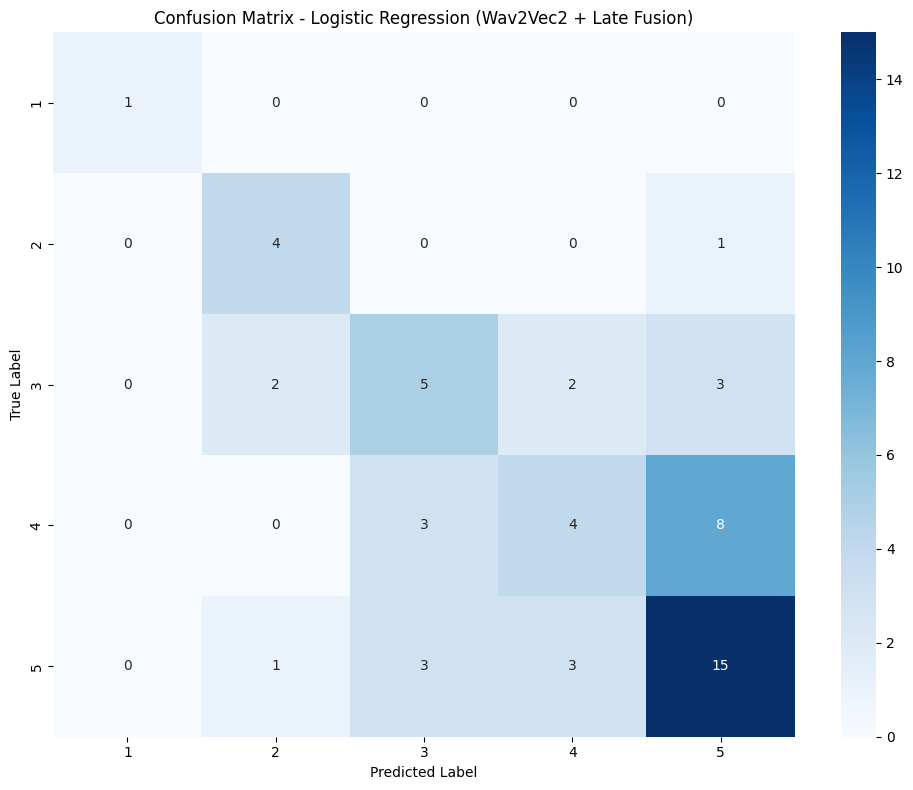

In [26]:
# =====================================================================
# LATE FUSION ANALYSIS & VISUALIZATION
# =====================================================================

print("\n" + "="*70)
print("LATE FUSION STRATEGY EXPLANATION")
print("="*70)
print("""
Late Fusion (Decision-Level Fusion):
- Extract Wav2Vec2 features from each of the 8 audio files per user
- Average (or pool) the feature vectors: mean([feat_1, ..., feat_8])
- Train classifier on fused features

Why Late Fusion works better:
1. Captures complementary information from different phonation/rhythm types
2. Robust to noise in individual recordings
3. Single decision per user (not 8 decisions)
4. Better generalization with averaged representations

Results:
""")

# Confusion matrix for best model
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

best_model_predictions = {
    0: svm_pred,
    1: lr_pred,
    2: xgb_pred
}

best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_pred = best_model_predictions[best_model_idx]

print(f"\n✓ Classification Report ({best_model_name}):")
print(classification_report(y_test, best_pred, target_names=[str(cls) for cls in label_encoder.classes_]))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name} (Wav2Vec2 + Late Fusion)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()